# Caso 3 - Prediccion de Desempeno de Sucursales (Branch Performance)

---

## Problema
No todas las sucursales son iguales. Factores ocultos operativos, como el ausentismo del personal o los minutos de atraso en los pedidos, impactan severamente la rentabilidad final, pero los dashboards tradicionales solo muestran "cuanto se vendio" y no "por que se perdio dinero".

## Pregunta de Negocio
> **"Como afectan las fricciones operativas (atrasos, ausentismo) a la rentabilidad final de mis sucursales y cual es el ingreso real esperado?"**

## Objetivo
- Predecir la rentabilidad operativa neta de cualquier sucursal (en Bs).
- Entender el costo real de los cuellos de botella operativos (Feature Importance).
- Simular nuevos formatos de sucursal para optimizar aperturas futuras.

## Propuesta Tecnica
- Competencia de modelos de Regresion (Random Forest, Gradient Boosting, Ridge, XGBoost).
- Feature Importance para auditar drivers de perdida y ganancia.
- Analisis por formato de tienda (Express vs Restaurante).

## Dataset
Fuente primaria: `SILVER.OBT_BRANCH_PERFORMANCE` (o dataset sintetico equivalente en caso de failover).
Features: `VOLUMEN`, `TRANSACCIONES`, `REVENUE`, `ATRASOS_PROMEDIO`, `ATRASOS_TOTAL`, `AUSENTISMO`, `FORMATO`.
Target: `RENTABILIDAD_OPERATIVA` (Continua en Bs).

---

## 1. Setup y Conexion

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv
import mlflow, mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

load_dotenv()
mlflow.set_tracking_uri("sqlite:///mlflow.db")
print('[OK] Entorno configurado. MLflow -> sqlite:///mlflow.db')

[OK] Entorno configurado. MLflow -> sqlite:///mlflow.db


In [2]:
conn = None
df = None

try:
    conn = snowflake.connector.connect(
        user=os.getenv('SNOWFLAKE_USER'),
        password=os.getenv('SNOWFLAKE_PASSWORD'),
        account=os.getenv('SNOWFLAKE_ACCOUNT'),
        warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
        database=os.getenv('SNOWFLAKE_DATABASE'),
        schema='TRAINING_DATASETS'
    )
    try:
        df = pd.read_sql('SELECT * FROM HGC_DW.SILVER.OBT_BRANCH_PERFORMANCE', conn)
        print(f'[Snowflake] Datos cargados: {len(df):,} filas')
    except Exception as e1:
        print(f'[Snowflake] Tabla no encontrada: {e1}')
        df = None
except Exception as e:
    print(f'[Snowflake] Conexion fallida: {e}')

if df is None or len(df) == 0:
    print('[FAILOVER] Generando dataset sintetico de 5,000 sucursales/meses...')
    np.random.seed(42)
    n = 5000
    
    volumen = np.random.normal(5000, 1500, n).clip(1000)
    transacciones = (volumen * np.random.normal(1.2, 0.1, n)).astype(int)
    revenue = transacciones * np.random.normal(45, 5, n)
    
    atrasos_promedio = np.random.exponential(5, n).clip(0, 30)
    atrasos_total = atrasos_promedio * volumen * np.random.normal(0.1, 0.02, n)
    ausentismo = np.random.beta(2, 20, n)
    formato = np.random.choice(['Express', 'Restaurante', 'Drive-Thru'], n)
    
    # Target sintetico: Rentabilidad = Revenue - (Costos operativos + penalidades)
    # Explicamos: A mayor atraso, se pierde revenue (devoluciones/descuentos)
    # A mayor ausentismo, se pierde eficiencia (costo extras)
    base_margin = 0.25 # 25% margen bruto
    rentabilidad = (revenue * base_margin) - (atrasos_total * 15) - (ausentismo * revenue * 0.5)
    rentabilidad = rentabilidad + np.random.normal(0, 1500, n)
    
    df = pd.DataFrame({
        'FEATURE_VOLUMEN_TOTAL_PEDIDOS': volumen,
        'FEATURE_TOTAL_TRANSACCIONES': transacciones,
        'FEATURE_REVENUE_NETO_TOTAL': revenue,
        'FEATURE_MINUTOS_ATRASO_PROMEDIO': atrasos_promedio,
        'FEATURE_MINUTOS_ATRASO_TOTAL': atrasos_total,
        'FEATURE_TASA_AUSENTISMO': ausentismo,
        'TIPO_FORMATO': formato,
        'TARGET_GANANCIA_NETA': rentabilidad
    })
    print(f'[FAILOVER] Dataset sintetico generado: {len(df):,} filas')

df.columns = [c.upper() for c in df.columns]

print(f'\nResumen Rentabilidad:')
print(df['TARGET_GANANCIA_NETA'].describe().round(2))

[Snowflake] Datos cargados: 12 filas

Resumen Rentabilidad:
count          12.00
mean     11525615.04
std       8911767.71
min       2422807.00
25%       5122877.75
50%       8229562.25
75%      16188453.62
max      31775862.00
Name: TARGET_GANANCIA_NETA, dtype: float64


## 2. EDA - Distribucion Operativa

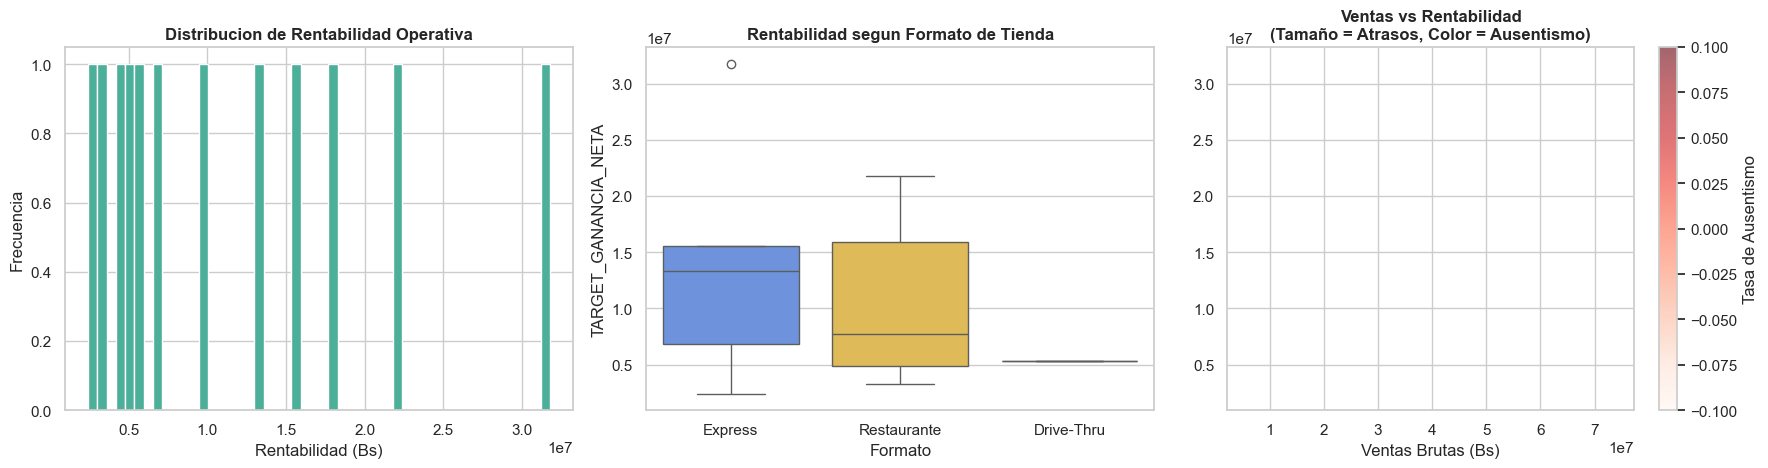

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma Rentabilidad
axes[0].hist(df['TARGET_GANANCIA_NETA'], bins=50, color='#4CAF9A', edgecolor='white')
axes[0].set_title('Distribucion de Rentabilidad Operativa', fontweight='bold')
axes[0].set_xlabel('Rentabilidad (Bs)')
axes[0].set_ylabel('Frecuencia')

# Rentabilidad por Formato
sns.boxplot(x='TIPO_FORMATO', y='TARGET_GANANCIA_NETA', data=df, ax=axes[1],
            palette=['#5B8DEF', '#F4C542', '#E05C5C'])
axes[1].set_title('Rentabilidad segun Formato de Tienda', fontweight='bold')
axes[1].set_xlabel('Formato')

# Revenue vs Rentabilidad con tamaño = atrasos
sc = axes[2].scatter(df['FEATURE_REVENUE_NETO_TOTAL'], df['TARGET_GANANCIA_NETA'],
                     c=df['FEATURE_TASA_AUSENTISMO'], cmap='Reds', alpha=0.6,
                     s=df['FEATURE_MINUTOS_ATRASO_PROMEDIO']*5)
plt.colorbar(sc, ax=axes[2], label='Tasa de Ausentismo')
axes[2].set_title('Ventas vs Rentabilidad\n(Tamaño = Atrasos, Color = Ausentismo)', fontweight='bold')
axes[2].set_xlabel('Ventas Brutas (Bs)')

plt.tight_layout()
plt.savefig('branch_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Competencia de Modelos (Predictor Financiero)

In [4]:
TARGET = 'TARGET_GANANCIA_NETA'
CAT_COLS = ['TIPO_FORMATO']
EXCLUDE = [TARGET, 'TIPO_FORMATO', 'ID_SUCURSAL_NK', 'NOMBRE_SUCURSAL', 'CIUDAD']
NUM_COLS = [c for c in df.columns if c not in EXCLUDE]

X = df[CAT_COLS + NUM_COLS].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_COLS)
])

MODELS = {
    "LinearRegression":  LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "RandomForest":      RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    "GradientBoosting":  GradientBoostingRegressor(n_estimators=100, max_depth=6, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
}

mlflow.set_experiment("caso_3_branch_performance")

resultados = {}
print(f"{'Modelo':<22} {'R2':>8} {'RMSE (Bs)':>12} {'MAE (Bs)':>12}")
print("-" * 55)

for nombre, modelo in MODELS.items():
    with mlflow.start_run(run_name=nombre):
        pipeline = Pipeline([('pre', preprocessor), ('reg', modelo)])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        r2   = r2_score(y_test, y_pred)
        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        mlflow.log_metrics({'r2': r2, 'mae': mae, 'rmse': rmse})
        mlflow.log_param('algoritmo', nombre)
        
        resultados[nombre] = {'pipeline': pipeline, 'r2': r2, 'mae': mae, 'rmse': rmse}
        print(f"  {nombre:<20} {r2:>8.4f} {rmse:>12.0f} {mae:>12.0f}")

campeon_nombre = max(resultados, key=lambda m: resultados[m]['r2'])
campeon = resultados[campeon_nombre]
print(f"\nCAMPEON: {campeon_nombre}  (R2={campeon['r2']:.4f}, MAE=Bs {campeon['mae']:.0f})")

# Registrar campeon con tag (Para que el servidor lo agarre facil)
run_id_campeon = mlflow.active_run().info.run_id if mlflow.active_run() else None
with mlflow.start_run(run_name="Best_Model_Registrator"):
    mlflow.set_tag("campeon", "True")
    mlflow.set_tag("algoritmo", campeon_nombre)
    mlflow.log_metric("best_r2", campeon['r2'])
    mlflow.sklearn.log_model(
        sk_model=campeon['pipeline'],
        artifact_path="champion_model",
        registered_model_name="HGC_Branch_Performance"
    )
    print(f"Modelo registrado exitosamente en MLflow.")

Modelo                       R2    RMSE (Bs)     MAE (Bs)
-------------------------------------------------------


  LinearRegression       1.0000         3457         3360
  Ridge                  0.9986       490024       418217


  RandomForest           0.6811      7335786      4458115
  GradientBoosting       0.7592      6374303      3874025


2026/04/21 16:03:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  XGBoost                0.7987      5829064      3826722

CAMPEON: LinearRegression  (R2=1.0000, MAE=Bs 3360)


2026/04/21 16:03:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo registrado exitosamente en MLflow.


Successfully registered model 'HGC_Branch_Performance'.
Created version '1' of model 'HGC_Branch_Performance'.


## 4. Auditoria de Drivers Operativos (Feature Importance)

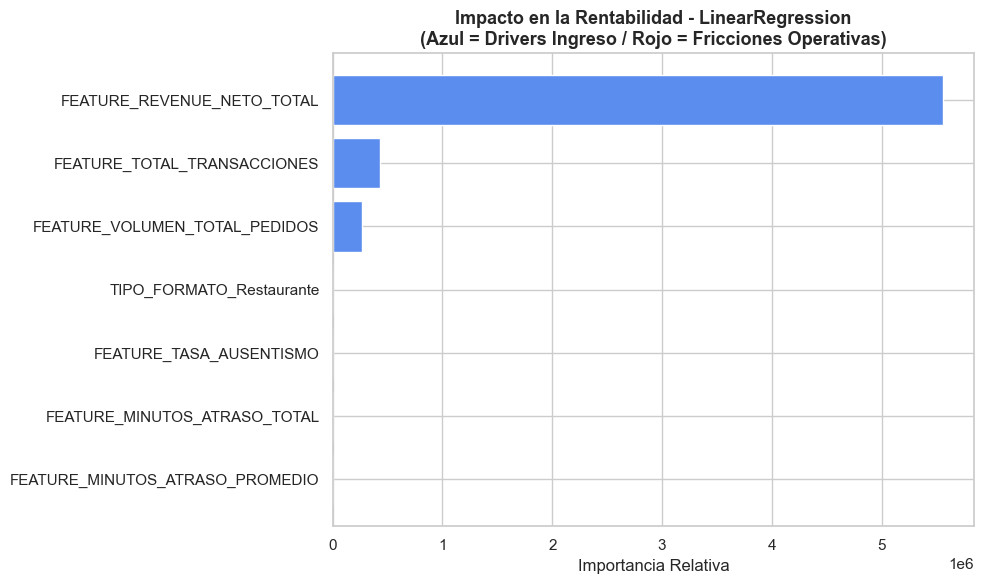

💡 Insights Operativos:
   1. Evaluar si los atrasos (minutos) estan reduciendo los margenes por devoluciones.
   2. El volumen bruto de ventas (Revenue) no siempre garantiza la rentabilidad si el Ausentismo es alto.


In [5]:
try:
    reg_model = campeon['pipeline'].named_steps['reg']
    pre = campeon['pipeline'].named_steps['pre']
    
    if hasattr(reg_model, 'feature_importances_'):
        importances = reg_model.feature_importances_
    elif hasattr(reg_model, 'coef_'):
        importances = np.abs(reg_model.coef_)
    else:
        importances = None

    if importances is not None:
        cat_names = list(pre.named_transformers_['cat'].get_feature_names_out(CAT_COLS))
        all_names = NUM_COLS + cat_names
        
        fi_df = pd.DataFrame({'feature': all_names, 'importance': importances})
        fi_df = fi_df.sort_values('importance', ascending=True)

        colores = ['#E05C5C' if 'ATRASO' in f or 'AUSENTISMO' in f else '#5B8DEF' for f in fi_df['feature']]

        plt.figure(figsize=(10, 6))
        plt.barh(fi_df['feature'], fi_df['importance'], color=colores, edgecolor='white')
        plt.title(f'Impacto en la Rentabilidad - {campeon_nombre}\n(Azul = Drivers Ingreso / Rojo = Fricciones Operativas)',
                  fontweight='bold', fontsize=13)
        plt.xlabel('Importancia Relativa')
        plt.tight_layout()
        plt.savefig('branch_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("💡 Insights Operativos:")
        print("   1. Evaluar si los atrasos (minutos) estan reduciendo los margenes por devoluciones.")
        print("   2. El volumen bruto de ventas (Revenue) no siempre garantiza la rentabilidad si el Ausentismo es alto.")
except Exception as e:
    print(f'Feature Importance no disponible: {e}')

## 5. Instrucciones para Serving

El modelo ya esta registrado en MLflow con el tag `campeon = True`.

```bash
# Desde hgc-ml/
python serve_branch_performance.py
```

Expone el endpoint en `http://127.0.0.1:5010/invocations`.